In [1]:
import pandas as pd
import os
from scipy.stats import binomtest
import sys
from pathlib import Path

# Add parent directory to sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

# Import the module
from helpers.fed_events_analysis import *


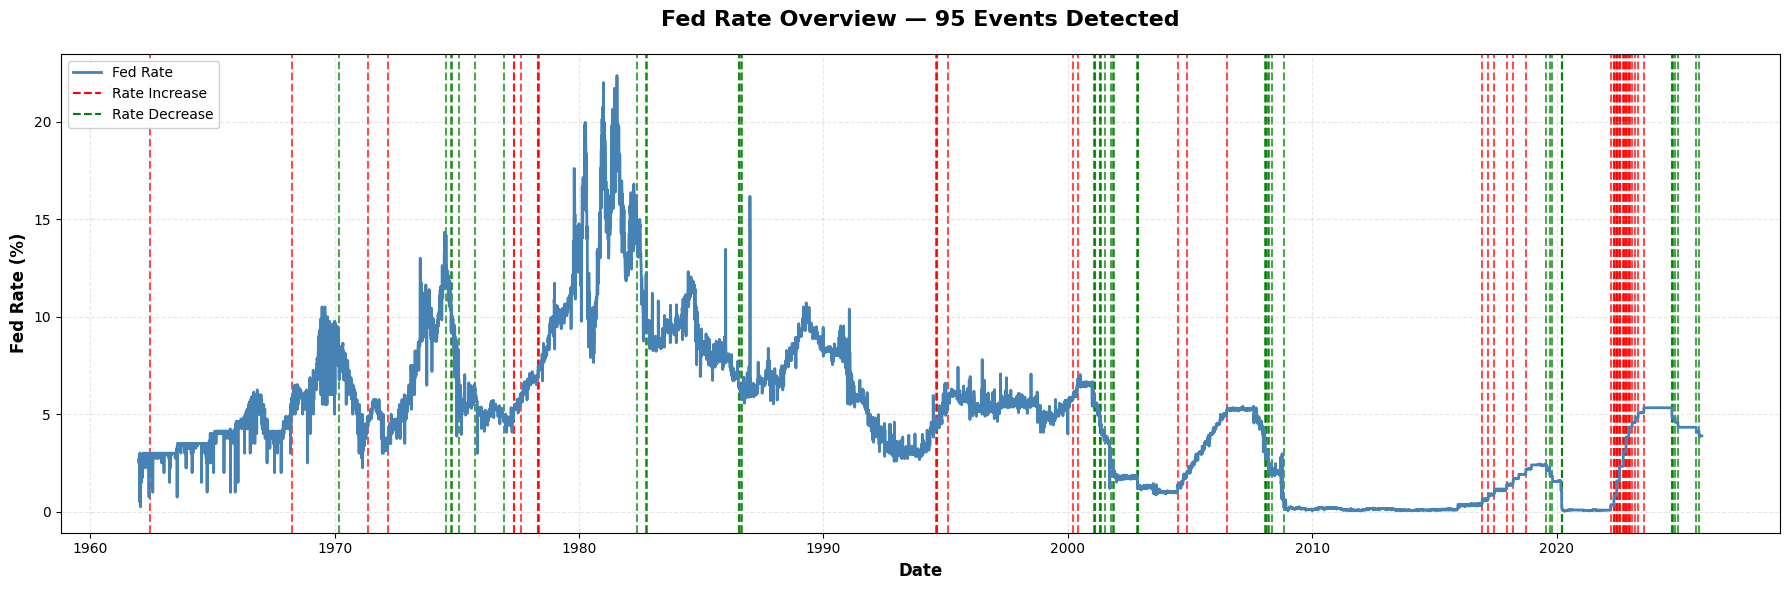

In [2]:
# Load Fed rates and generate signals
df_fed_rates = pd.read_csv("../fed_rate_1962_today.csv")

signals = identify_fed_rate_signals(
    df_fed_rates,
    window_size=28,
    transition_window=3,
    central_metric="robust",
    alfa=0.8,
    min_delta=0.2,
    max_delta=2,
    skip_days=5,
    stability_days=21,
    stability_fraction=0.5,
    verbose=False,
)

# Plot the signals
plot_fed_rate_overview(
    df_fed_rates,
    signals)

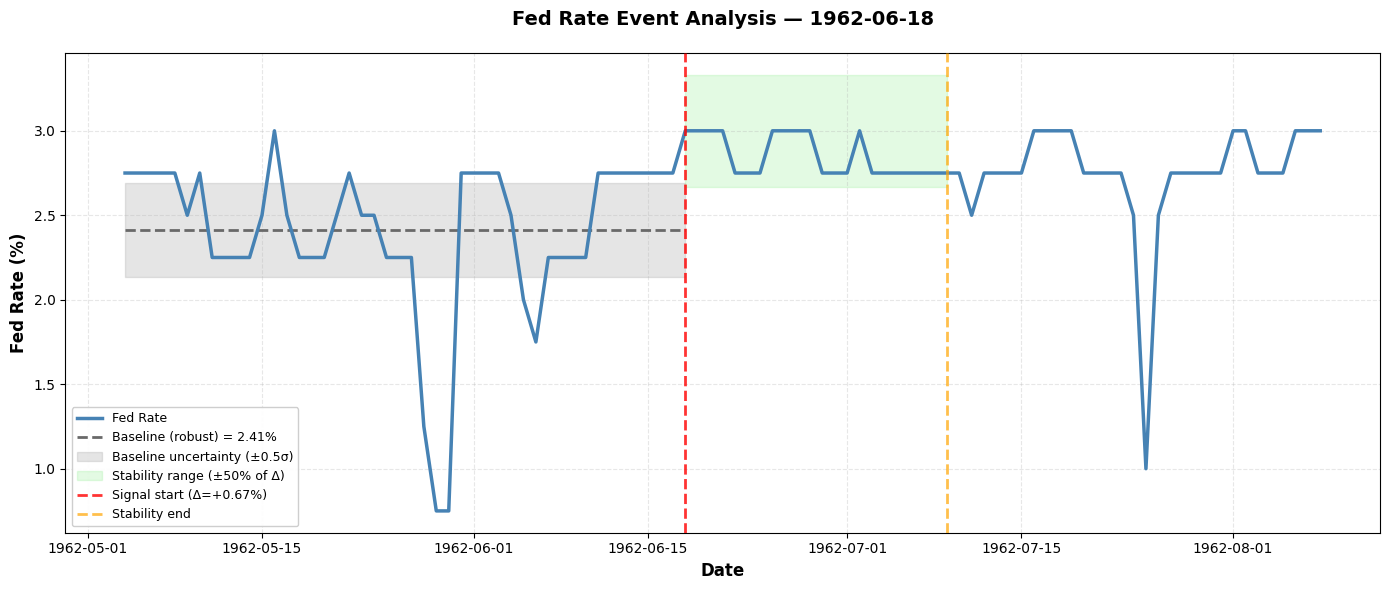

In [ ]:
for period_index in range(10):
    plot_single_fed_rate_period(df_fed_rates,signals,period_index=period_index,show=False)

In [7]:
print("Number of signals detected:", len(signals))
signals

Number of signals detected: 95


[('1962-06-18', '1962-07-09', np.float64(0.6652)),
 ('1968-04-02', '1968-04-23', np.float64(0.6509)),
 ('1970-03-04', '1970-03-25', np.float64(-1.5359)),
 ('1971-05-18', '1971-06-08', np.float64(0.5057)),
 ('1972-03-14', '1972-04-04', np.float64(0.742)),
 ('1974-07-29', '1974-08-19', np.float64(-1.2362)),
 ('1974-10-11', '1974-11-01', np.float64(-1.0745)),
 ('1974-10-21', '1974-11-11', np.float64(-1.0521)),
 ('1975-02-07', '1975-02-28', np.float64(-0.8112)),
 ('1975-10-07', '1975-10-28', np.float64(-0.4705)),
 ('1976-12-01', '1976-12-22', np.float64(-0.2934)),
 ('1977-05-02', '1977-05-23', np.float64(0.6257)),
 ('1977-05-07', '1977-05-28', np.float64(0.5361)),
 ('1977-08-12', '1977-09-02', np.float64(0.3871)),
 ('1978-04-28', '1978-05-19', np.float64(0.4412)),
 ('1978-05-03', '1978-05-24', np.float64(0.5932)),
 ('1978-05-09', '1978-05-30', np.float64(0.4125)),
 ('1982-05-21', '1982-06-11', np.float64(-1.36)),
 ('1982-10-06', '1982-10-27', np.float64(-0.8314)),
 ('1982-10-15', '1982-11-

In [ ]:
# Pairs of ETFs and Stocks
# Each ETF countains multiple stocks from a specific sector, for example for the Technology sector, the ETF "XLK" includes stocks like "AAPL", "MSFT", etc.
# We only pair the important stocks of an ETF with the stock itself.
# This mapping is stored in etf_stock_map.csv
pairs = pd.read_csv("../data/etf_stock_map.csv")
pval_threshold = 0.1

posfed_results, negfed_results = [], []

for _, row in pairs.iterrows():
    etf, stock, sector = row["ETF"], row["Component"], row["Sector"]
    etf_path = f"../data/etfs+fedrate+nmv/{etf}.csv"
    stock_path = f"../data/stocks+fedrate+nmv/{stock}.csv"
    
    if not os.path.exists(etf_path) or not os.path.exists(stock_path):
        continue
    
    tickers = {etf: pd.read_csv(etf_path), stock: pd.read_csv(stock_path)}
    
    try:
        # Get common event for analysis
        common_events = get_common_fed_event_periods(fed_events=signals, stocks_data=tickers, pre_days=21, post_days=21)

        # Analyze outperformance
        result = fed_outperformance_area(tickers, common_events, normalize=True, metric="counts")

        # Statistical significance testing
        n_pos_wins = result.loc[0, "Counts_Area_PosFed"]
        n_neg_wins = result.loc[0, "Counts_Area_NegFed"]
        n_pos_total = result.loc[0, "N_events_PosFed"]
        n_neg_total = result.loc[0, "N_events_NegFed"]
        
        pval_pos = binomtest(n_pos_wins, n_pos_total, 0.5, alternative="two-sided").pvalue
        pval_neg = binomtest(n_neg_wins, n_neg_total, 0.5, alternative="two-sided").pvalue
        
        if pval_pos < pval_threshold or pval_neg < pval_threshold:
            res = fed_outperformance_area(tickers, common_events, normalize=True, metric="percentage")
            data = res.loc[0].to_dict()
            data.update({"Sector": sector, "ETF": etf, "Component": stock})
            
            if pval_pos < pval_threshold:
                posfed_results.append({**data, "fed_sign": "PosFed", "pval": pval_pos})
            if pval_neg < pval_threshold:
                negfed_results.append({**data, "fed_sign": "NegFed", "pval": pval_neg})
    except:
        continue

df_posFed, df_negFed = pd.DataFrame(posfed_results), pd.DataFrame(negfed_results)

print("\nSignificant Positive Fed results by sector:")
for sector, group in df_posFed.groupby("Sector"):
    print(f"\nSector: {sector}")
    print(group[["ETF", "Component", "Percentage_Area_PosFed", "N_events_PosFed", "pval"]].sort_values("Percentage_Area_PosFed", ascending=False).to_string(index=False))

print("\nSignificant Negative Fed results by sector:")
for sector, group in df_negFed.groupby("Sector"):
    print(f"\nSector: {sector}")
    print(group[["ETF", "Component", "Percentage_Area_NegFed", "N_events_NegFed", "pval"]].sort_values("Percentage_Area_NegFed", ascending=False).to_string(index=False))



Significant Positive Fed results by sector:

Sector: Consumer_Discretionary
ETF Component  Percentage_Area_PosFed  N_events_PosFed     pval
IYC      BKNG               88.888889                9 0.039062

Sector: Energy
ETF Component  Percentage_Area_PosFed  N_events_PosFed    pval
XLE       EOG               18.181818               11 0.06543
PBW       RUN                0.000000                6 0.03125

Sector: Financials
 ETF Component  Percentage_Area_PosFed  N_events_PosFed     pval
 VFH        MS               88.888889                9 0.039062
 IYF        MS               88.888889                9 0.039062
FNCL       JPM                0.000000                6 0.031250

Sector: Healthcare
ETF Component  Percentage_Area_PosFed  N_events_PosFed     pval
XBI      ALNY                   100.0                7 0.015625

Sector: Technology
ETF Component  Percentage_Area_PosFed  N_events_PosFed    pval
QQQ      AAPL               18.181818               11 0.06543

Significant Neg

In [24]:
# Test on a specific ETF and Stock pair
tickers = {
    "FDN": pd.read_csv("../data/etfs+fedrate+nmv/FDN.csv"),
    "CRM": pd.read_csv("../data/stocks+fedrate+nmv/CRM.csv")
}

common_events = get_common_fed_event_periods(
    fed_events=signals,
    stocks_data=tickers,
    pre_days=28,
    post_days=21
)

Plotting 5 positive and 5 negative events.

Positive event 12: date=2018-09-27, ΔFed=+0.2605


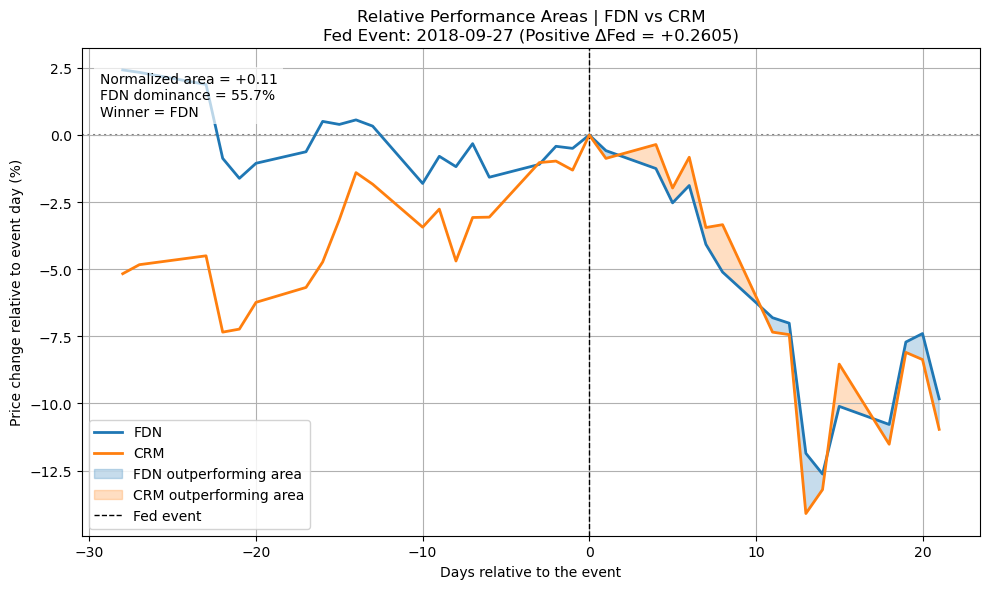


Positive event 11: date=2018-03-22, ΔFed=+0.2604


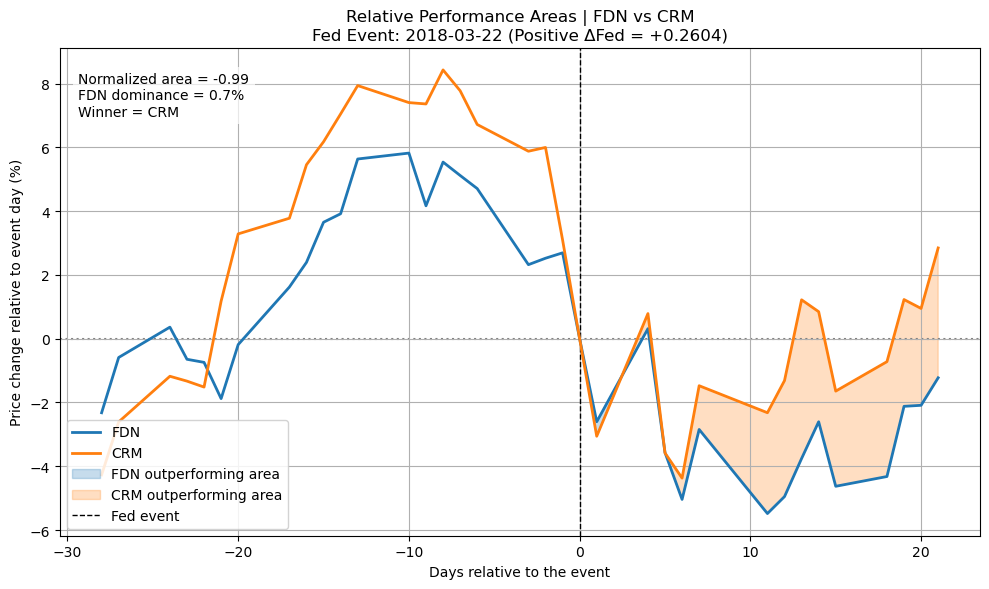


Positive event 7: date=2016-12-15, ΔFed=+0.2518


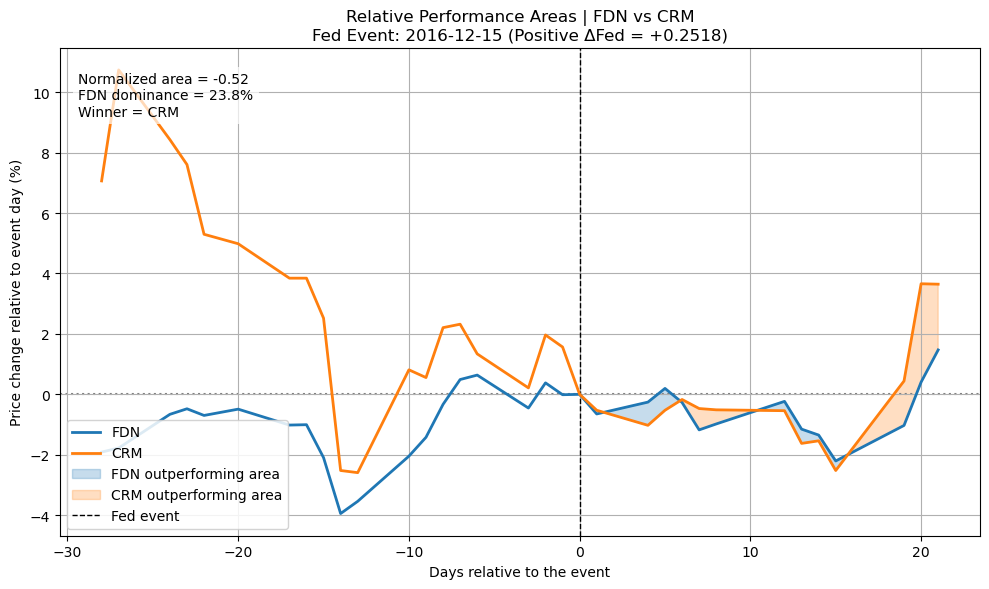


Positive event 8: date=2017-03-16, ΔFed=+0.2516


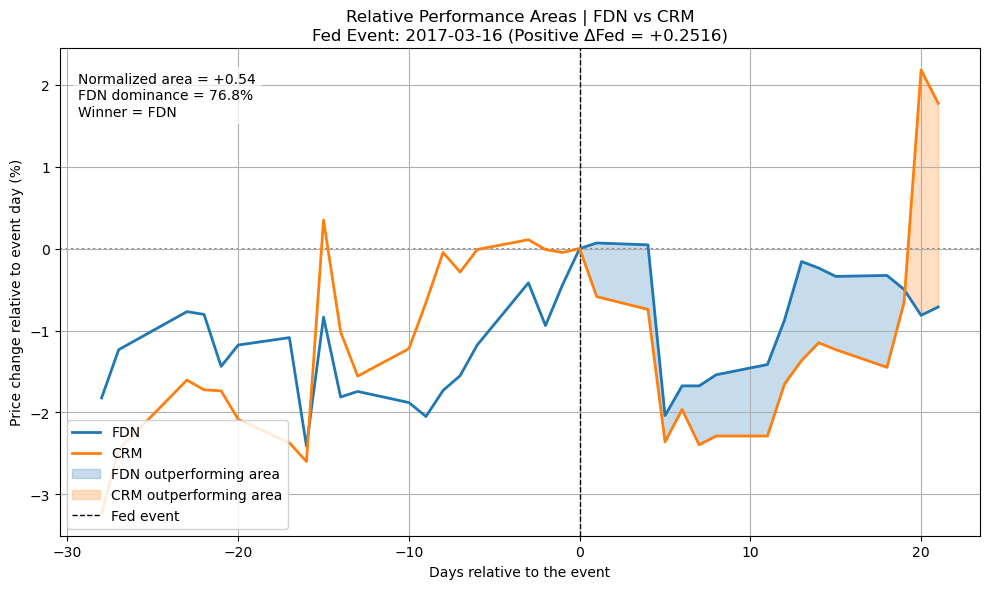


Positive event 10: date=2017-12-14, ΔFed=+0.2516


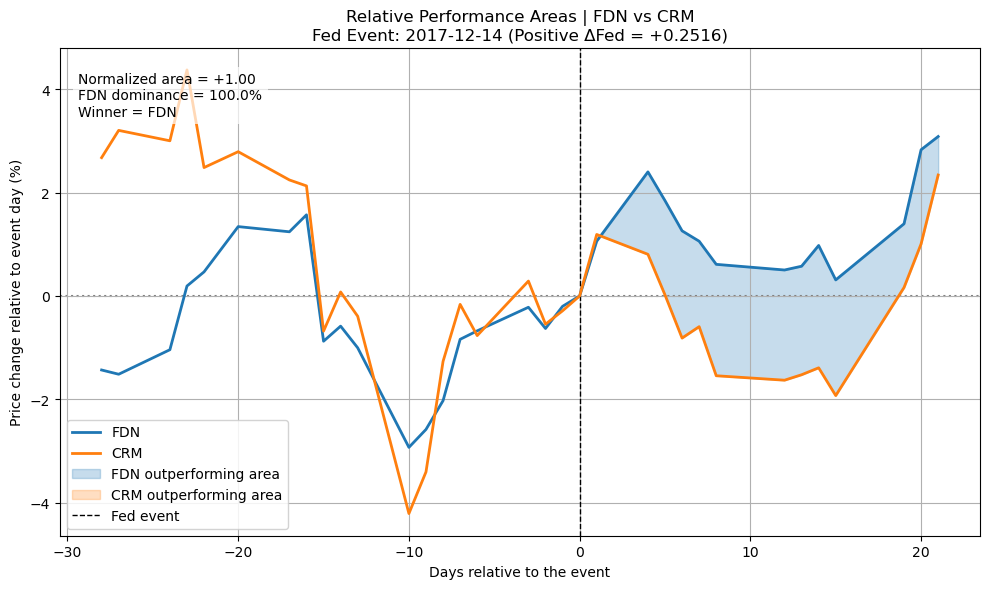


Negative event 0: date=2008-02-01, ΔFed=-0.9809


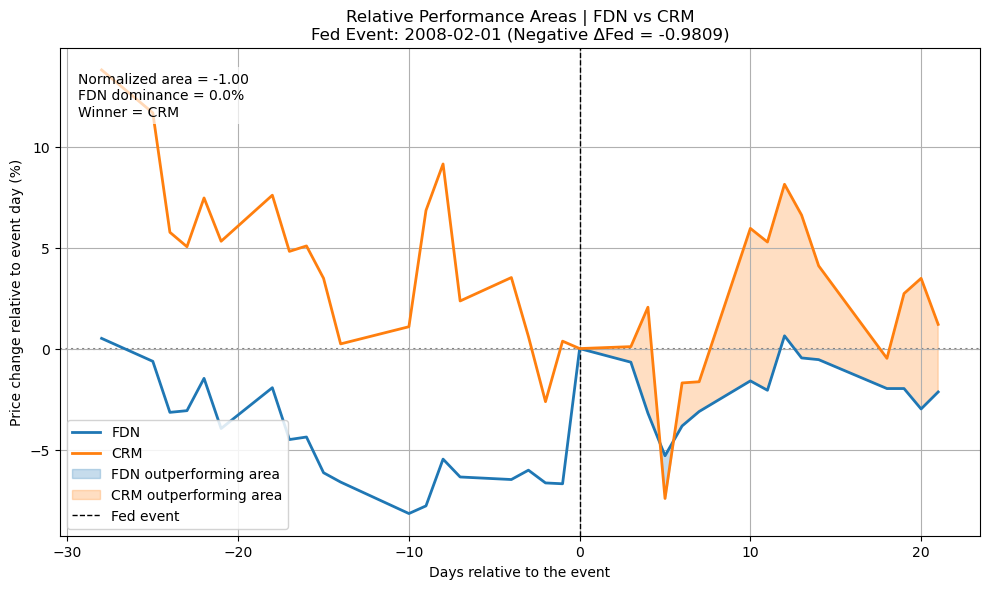


Negative event 3: date=2008-03-18, ΔFed=-0.8132


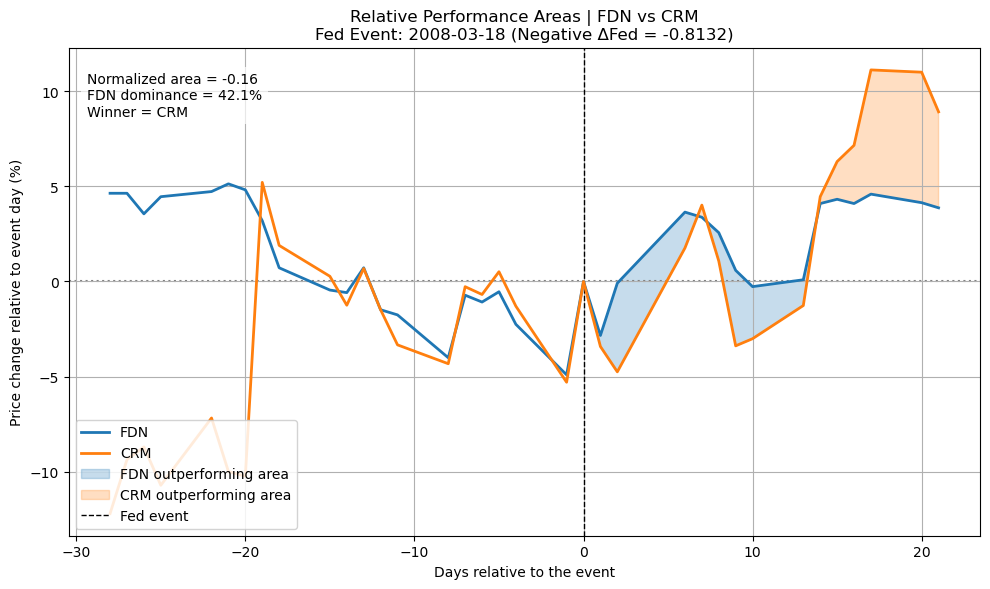


Negative event 1: date=2008-02-06, ΔFed=-0.7468


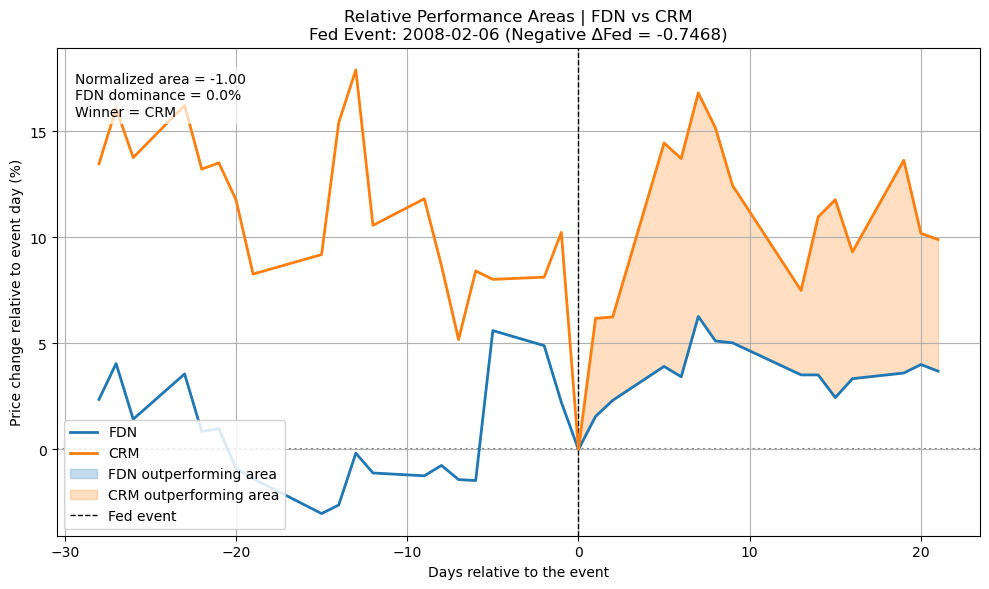


Negative event 6: date=2008-10-29, ΔFed=-0.6716


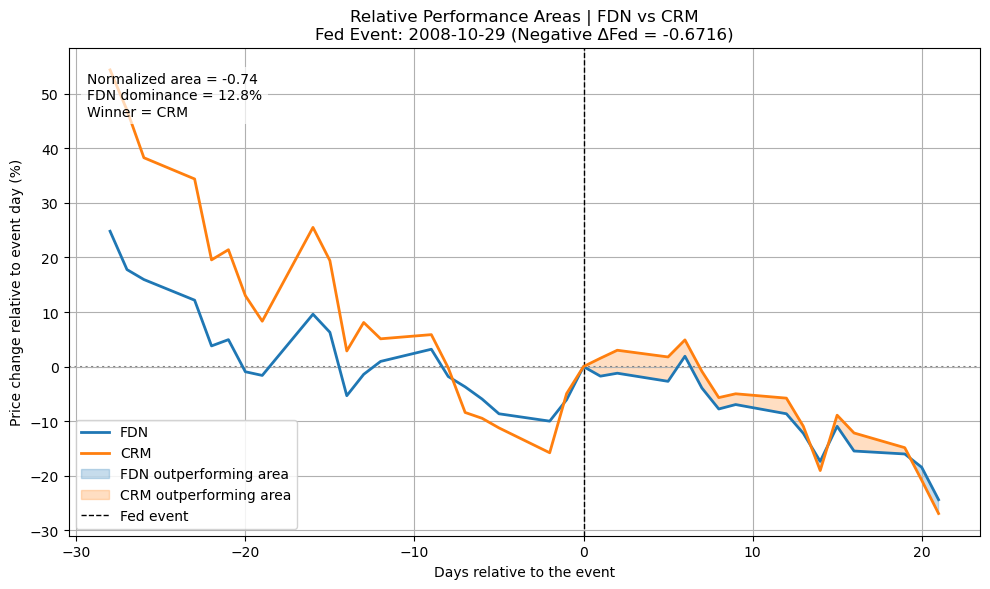


Negative event 2: date=2008-02-11, ΔFed=-0.6130


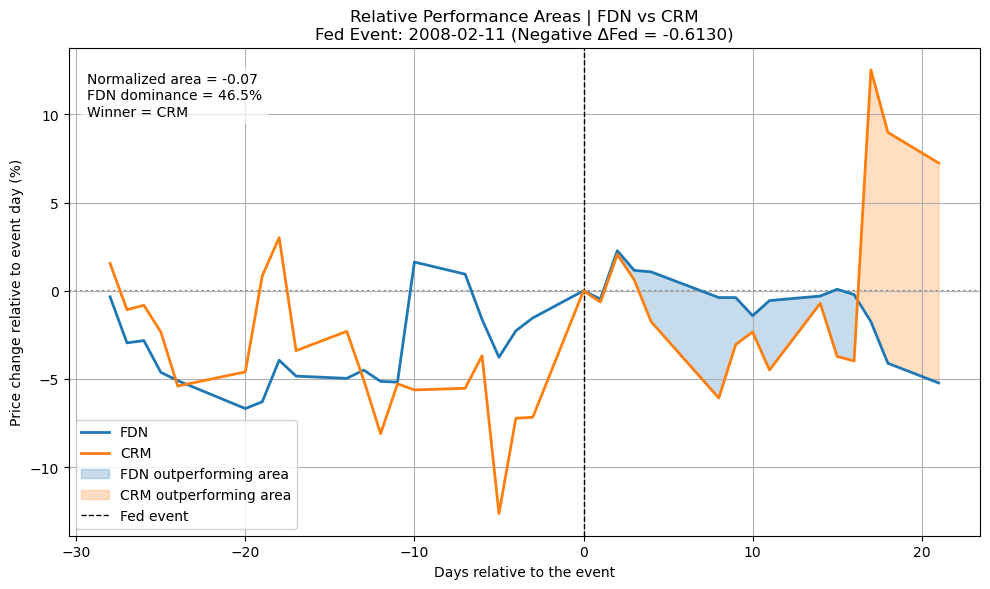

In [25]:
plot_fed_area_dominance_events(
    tickers= tickers,
    events=common_events,
    pre_days=28,
    post_days=21,
    top_n_pos=5,
    top_n_neg=5,
    show_dominance=True
)

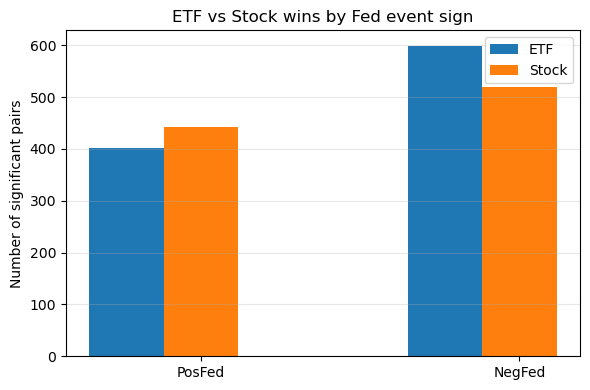

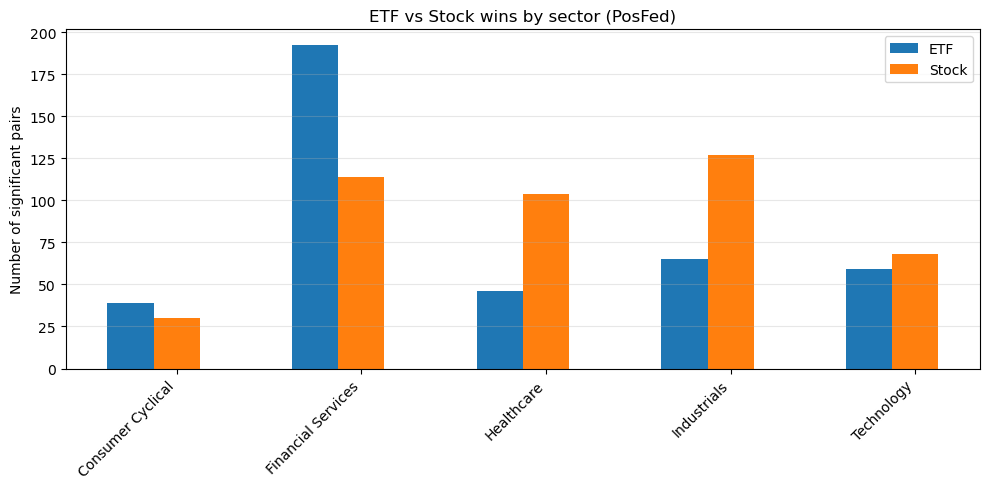

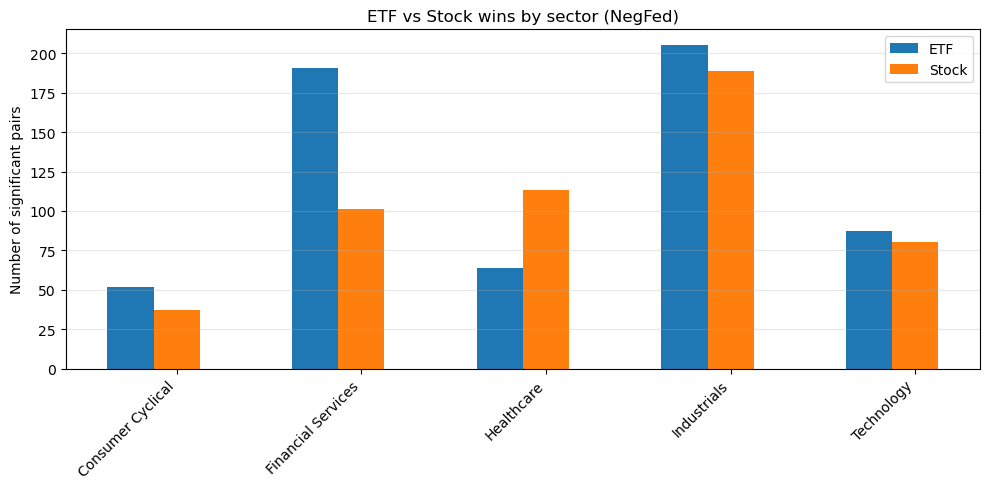

In [26]:

df_pos = add_winner_info(df_posFed, "Percentage_Area_PosFed", "PosFed")
df_neg = add_winner_info(df_negFed, "Percentage_Area_NegFed", "NegFed")
df_all = pd.concat([df_pos, df_neg], ignore_index=True)

plot_overall_wins(df_all)
plot_wins_by_sector(df_all, "PosFed")
plot_wins_by_sector(df_all, "NegFed")


We can see that when there is a positive fed event (FED rate increase), Stocks tend to react better than ETF. 
On the contrary, when there is a negative FED event (FED rate decrease), ETF tend to react better.

If we look closer on the positive fed event, we can see that Stocks, is clearly wining in Healthcare and industrial sectors, winning in technology, losing in consumer cyclical and clearly losing in financial services.

Now, let’s focus on the Negative fed event. We can see the same trend for Consumer Cyclical Financial Services, Healthcare.

However, for Industrial, ETF are winning, same in technology.

The explanasion ?????????????

In [10]:

pair_summary = build_pair_summary(df_all)
print(pair_summary.head(30).to_string(index=False))

                Sector Fed_sign_type  ETF Component Winner     Metric  N_events     pval
Consumer_Discretionary        NegFed  IYC       LOW  Stock  30.434783        23 0.093140
Consumer_Discretionary        NegFed  IYC      SBUX    ETF  73.913043        23 0.034690
Consumer_Discretionary        NegFed  XLY      SBUX    ETF  69.565217        23 0.093140
Consumer_Discretionary        PosFed  IYC      BKNG    ETF  88.888889         9 0.039062
                Energy        NegFed  OIH       HAL  Stock  20.000000        20 0.011818
                Energy        NegFed  FCG       EQT    ETF  90.000000        10 0.021484
                Energy        NegFed  PXE       COP    ETF  90.000000        10 0.021484
                Energy        NegFed  XLE       COP    ETF  69.565217        23 0.093140
                Energy        NegFed  IYE       COP    ETF  69.565217        23 0.093140
                Energy        PosFed  XLE       EOG  Stock  18.181818        11 0.065430
                Energ

In [14]:
import os
import pandas as pd
from scipy.stats import binomtest
from joblib import Parallel, delayed
from tqdm.notebook import tqdm  # mostra barra di avanzamento

# --- Caricamento dati ---
pairs = pd.read_csv("../data/ticker_sector_pairs.csv")
meta = pd.read_csv("../data/symbols_valid_meta_augmented_with_dates.csv")

pval_threshold = 0.1

# --- Funzione di elaborazione ---
def process_pair(row):
    tickerA, tickerB, sector = row["tickerA"], row["tickerB"], row["sector"]

    try:
        # Path picker in base a ETF o Stock
        tickerA_path = (
            f"../data/etfs+fedrate+nmv/{tickerA}.csv"
            if meta.loc[meta["Symbol"] == tickerA, "ETF"].iloc[0] == "Y"
            else f"../data/stocks+fedrate+nmv/{tickerA}.csv"
        )
        tickerB_path = (
            f"../data/etfs+fedrate+nmv/{tickerB}.csv"
            if meta.loc[meta["Symbol"] == tickerB, "ETF"].iloc[0] == "Y"
            else f"../data/stocks+fedrate+nmv/{tickerB}.csv"
        )

        if not os.path.exists(tickerA_path) or not os.path.exists(tickerB_path):
            return None

        tickers = {
            tickerA: pd.read_csv(tickerA_path),
            tickerB: pd.read_csv(tickerB_path),
        }

        common_events = get_common_fed_event_periods(
            fed_events=signals, stocks_data=tickers, pre_days=21, post_days=21
        )

        result = fed_outperformance_area(tickers, common_events, normalize=True, metric="counts")

        n_pos_wins = result.loc[0, "Counts_Area_PosFed"]
        n_neg_wins = result.loc[0, "Counts_Area_NegFed"]
        n_pos_total = result.loc[0, "N_events_PosFed"]
        n_neg_total = result.loc[0, "N_events_NegFed"]

        pval_pos = binomtest(n_pos_wins, n_pos_total, 0.5, alternative="two-sided").pvalue
        pval_neg = binomtest(n_neg_wins, n_neg_total, 0.5, alternative="two-sided").pvalue

        results = {"pos": None, "neg": None}

        if pval_pos < pval_threshold or pval_neg < pval_threshold:
            res = fed_outperformance_area(tickers, common_events, normalize=True, metric="percentage")
            data = res.loc[0].to_dict()
            data.update({"Sector": sector, "TickerA": tickerA, "TickerB": tickerB})

            if pval_pos < pval_threshold:
                results["pos"] = {**data, "fed_sign": "PosFed", "pval": pval_pos}
            if pval_neg < pval_threshold:
                results["neg"] = {**data, "fed_sign": "NegFed", "pval": pval_neg}

        return results if any(results.values()) else None

    except Exception:
        return None

# --- Esecuzione parallela ---
# n_jobs = -1 usa tutti i core disponibili
results = Parallel(n_jobs=-1)(
    delayed(process_pair)(row) for row in tqdm(pairs.to_dict("records"))
)

posfed_results = [r["pos"] for r in results if r and r["pos"]]
negfed_results = [r["neg"] for r in results if r and r["neg"]]

df_posFed = pd.DataFrame(posfed_results)
df_negFed = pd.DataFrame(negfed_results)

# --- Output ordinato ---
print("\nSignificant Positive Fed results by sector:")
for sector, group in df_posFed.groupby("Sector"):
    print(f"\nSector: {sector}")
    print(
        group[
            ["TickerA", "TickerB", "Percentage_Area_PosFed", "N_events_PosFed", "pval"]
        ]
        .sort_values("Percentage_Area_PosFed", ascending=False)
        .to_string(index=False)
    )

print("\nSignificant Negative Fed results by sector:")
for sector, group in df_negFed.groupby("Sector"):
    print(f"\nSector: {sector}")
    print(
        group[
            ["TickerA", "TickerB", "Percentage_Area_NegFed", "N_events_NegFed", "pval"]
        ]
        .sort_values("Percentage_Area_NegFed", ascending=False)
        .to_string(index=False)
    )

  0%|          | 0/34307 [00:00<?, ?it/s]


Significant Positive Fed results by sector:

Sector: Consumer Cyclical
TickerA TickerB  Percentage_Area_PosFed  N_events_PosFed     pval
   ALSN     LKQ              100.000000                6 0.031250
   ALSN     LEN              100.000000                6 0.031250
   ALSN     HOG              100.000000                6 0.031250
   ALSN      GT              100.000000                6 0.031250
   ALSN    APTV              100.000000                6 0.031250
    FXG    GRMN              100.000000                6 0.031250
    FXD     NWL              100.000000                6 0.031250
  DISCK     NWL              100.000000                6 0.031250
  DISCK      GT              100.000000                6 0.031250
    BJK    FDIS              100.000000                6 0.031250
   BFAM    CHTR              100.000000                6 0.031250
   BFAM     RCL              100.000000                6 0.031250
    FXG     NWL              100.000000                6 0.031250
   F

In [ ]:
import pandas as pd
from collections import Counter

def count_wins_by_sector(df, fed_type="PosFed"):
    """
    Count wins and total matches for each ticker and sector.

    Parameters:
      df : Reference DataFrame (df_posFed or df_negFed)
      fed_type : "PosFed" or "NegFed"

    Rules:
      - A wins if Percentage_Area_*Fed > 50
      - B wins if Percentage_Area_*Fed < 50
      - no winner if == 50

    Output:
      DataFrame with [Sector, Ticker, Wins, Matches, WinRate]
    """
    col = f"Percentage_Area_{fed_type}"

    winners_by_sector = []
    matches_by_sector = []

    for _, row in df.iterrows():
        sector = row["Sector"]
        val = row.get(col, None)
        if pd.isna(val):
            continue

        tickerA, tickerB = row["TickerA"], row["TickerB"]

        # record the "match" (both tickers participate)
        matches_by_sector.extend([(sector, tickerA), (sector, tickerB)])

        # record the winner
        if val > 50:
            winners_by_sector.append((sector, tickerA))
        elif val < 50:
            winners_by_sector.append((sector, tickerB))
        # if val == 50 → no winner

    # Counts
    win_counts = Counter(winners_by_sector)
    match_counts = Counter(matches_by_sector)

    # Build DataFrame
    data = []
    for (sector, ticker), total_matches in match_counts.items():
        wins = win_counts.get((sector, ticker), 0)
        data.append((sector, ticker, wins))

    out = (
        pd.DataFrame(data, columns=["Sector", "Ticker", "Wins"])
        .sort_values(["Sector", "Wins"], ascending=[True, False])
        .reset_index(drop=True)
    )

    return out


In [16]:
df_posWins = count_wins_by_sector(df_posFed, fed_type="PosFed")
df_negWins = count_wins_by_sector(df_negFed, fed_type="NegFed")



In [17]:
df_posWins

,Sector,Ticker,Wins
0,Consumer Cyclical,MCD,9
1,Consumer Cyclical,PHM,7
2,Consumer Cyclical,BH,6
3,Consumer Cyclical,ARKR,6
4,Consumer Cyclical,ALSN,5
...,...,...,...
383,Technology,APH,0
384,Technology,BDC,0
385,Technology,AMAT,0
386,Technology,FDN,0


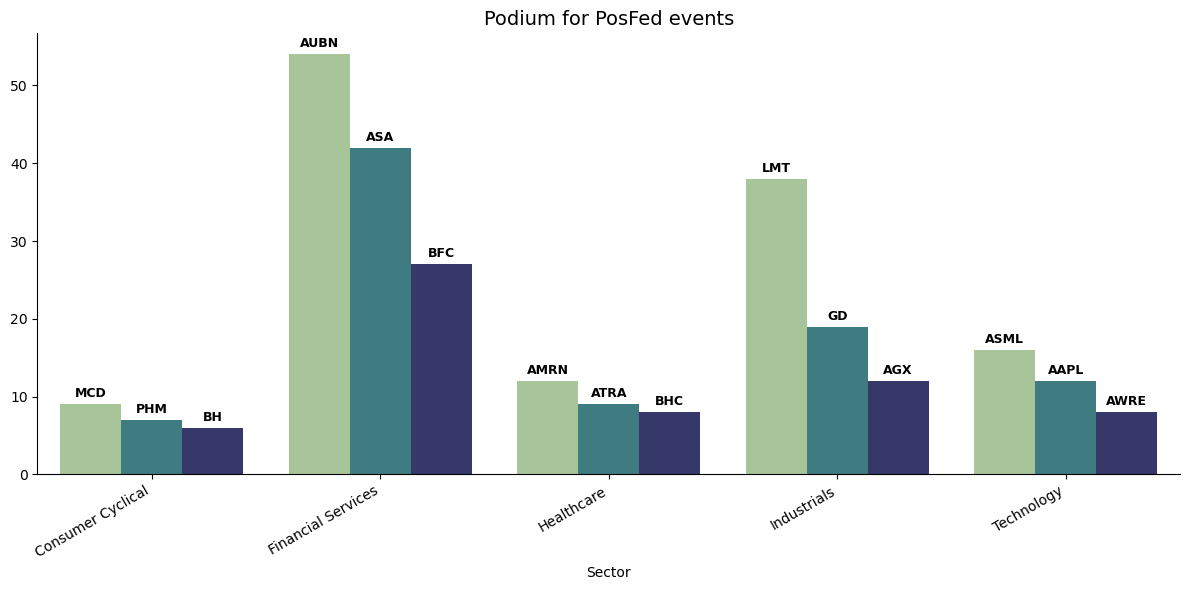

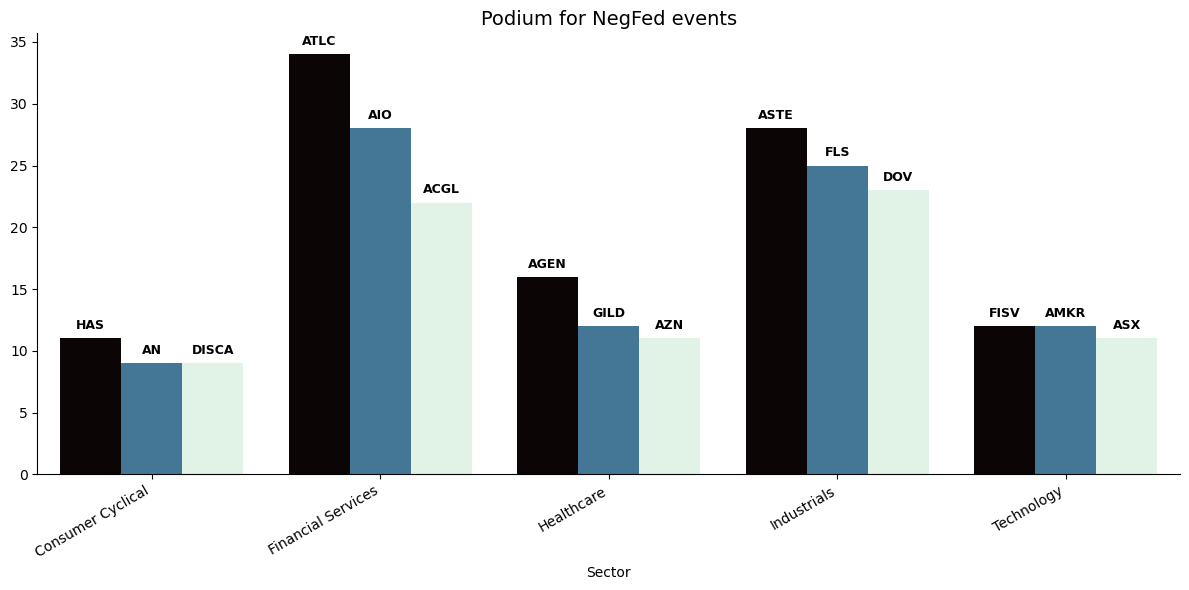

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_sector_podi(df, title="Podium by sector", palette="viridis"):
    """
    Podium (top 3) by sector, with correct names on each bar and no legend.
    """
    # Select top 3 by sector
    df_podi = (
        df.sort_values(["Sector", "Wins"], ascending=[True, False])
        .groupby("Sector")
        .head(3)
        .copy()
    )

    # Rank (1/2/3)
    df_podi["Rank"] = (
        df_podi.groupby("Sector")["Wins"]
        .rank(method="first", ascending=False)
        .astype(int)
    )

    # Sector order
    sectors = df_podi["Sector"].unique()
    ranks = sorted(df_podi["Rank"].unique())
    n_hues = len(ranks)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=df_podi,
        x="Sector",
        y="Wins",
        hue="Rank",
        palette=palette,
        dodge=True,
    )
    ax.get_legend().remove()

    # Calculate the position of each bar manually
    group_width = 0.8  # total width per group (seaborn default)
    bar_width = group_width / n_hues

    # Create a mapping Rank -> bar offset
    offsets = {
        rank: (-group_width / 2 + bar_width / 2) + (i * bar_width)
        for i, rank in enumerate(ranks)
    }

    # Now add labels based on rank and sector
    for i, (sector, subdf) in enumerate(df_podi.groupby("Sector")):
        for _, row in subdf.iterrows():
            rank = row["Rank"]
            x_pos = i + 1 + offsets[rank] - 1  # align to correct tick
            y_pos = row["Wins"]
            ax.text(
                x_pos,
                y_pos + 0.5,
                row["Ticker"],
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
            )

    # Improve X axis
    plt.title(title, fontsize=14)
    plt.ylabel("")
    plt.xlabel("Sector")
    plt.xticks(rotation=30, ha="right")

    sns.despine()
    plt.tight_layout()
    plt.show()

plot_sector_podi(df_posWins, title="Podium for PosFed events", palette="crest")
plot_sector_podi(df_negWins, title="Podium for NegFed events", palette="mako")


We can see the best companies reacting to Positive and Negative FED events. 
This can be useful to have example for the game.
Than go to the general case (up)

In [29]:
# ============================================================
# 📘 COMPARISON BETWEEN PosFed AND NegFed RANKINGS (by sector, with post-filter rank)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# Parameter: minimum wins required in each dataset
min_wins = 2  # you can increase it (e.g., 3 or 5) for more rigor

# 1️⃣ Find common tickers
common_tickers = set(df_posWins["Ticker"]).intersection(df_negWins["Ticker"])
print(f"Common tickers found: {len(common_tickers)}")

# Filter only common tickers and apply min_wins
df_pos_common = df_posWins[df_posWins["Ticker"].isin(common_tickers) & (df_posWins["Wins"] >= min_wins)].copy()
df_neg_common = df_negWins[df_negWins["Ticker"].isin(common_tickers) & (df_negWins["Wins"] >= min_wins)].copy()

# 2️⃣ Merge only tickers present in both (same sector)
df_compare = pd.merge(
    df_pos_common[["Sector", "Ticker", "Wins"]],
    df_neg_common[["Sector", "Ticker", "Wins"]],
    on=["Sector", "Ticker"],
    suffixes=("_Pos", "_Neg"),
)

# Filter further if needed (optional example)
# df_compare = df_compare[df_compare["Sector"] != "Consumer Cyclical"]

# 3️⃣ Calculate ranks *post-filters*, independent by sector
def compute_ranks_after_filter(df):
    ranked = []
    for sector, group in df.groupby("Sector"):
        # sort and assign rank 1..N for Pos and Neg
        group = group.sort_values("Wins_Pos", ascending=False).copy()
        group["PosRank"] = range(1, len(group) + 1)
        group = group.sort_values("Wins_Neg", ascending=False).copy()
        group["NegRank"] = range(1, len(group) + 1)
        ranked.append(group)
    return pd.concat(ranked, ignore_index=True)

df_compare = compute_ranks_after_filter(df_compare)

print(f"✅ Combined dataset ready (min_wins = {min_wins})")
display(df_compare.head())

# 4️⃣ Calculate dynamic limits (centered on data)
xmax = df_compare["PosRank"].max()
ymax = df_compare["NegRank"].max()
lim = max(xmax, ymax) + 1

# Exclude sectors with too few entries, for example Consumer Cyclical
df_compare = df_compare[df_compare["Sector"] != "Consumer Cyclical"]

# 5️⃣ Consistent palette and fixed colors for each sector
sectors = sorted(df_compare["Sector"].unique())
sector_colors = px.colors.qualitative.Plotly
color_map = {sec: sector_colors[i % len(sector_colors)] for i, sec in enumerate(sectors)}

# 6️⃣ Interactive plot with dropdown
fig = go.Figure()

for sec in sectors:
    subset = df_compare[df_compare["Sector"] == sec]
    fig.add_trace(
        go.Scatter(
            x=subset["PosRank"],
            y=subset["NegRank"],
            mode="markers",
            name=sec,
            marker=dict(size=10, opacity=0.8, color=color_map[sec]),
            text=subset["Ticker"],
            customdata=subset[["Wins_Pos", "Wins_Neg"]],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "Sector: " + sec + "<br>"
                "Rank PosFed: %{x}<br>"
                "Rank NegFed: %{y}<br>"
                "Wins PosFed: %{customdata[0]}<br>"
                "Wins NegFed: %{customdata[1]}<extra></extra>"
            ),
            visible=True if sec == sectors[0] else False,
        )
    )

# Reference diagonal
fig.add_shape(
    type="line",
    x0=1, y0=1,
    x1=lim, y1=lim,
    line=dict(color="gray", dash="dot", width=1),
)

# Axes (inverted and centered)
fig.update_xaxes(
    autorange="reversed",
    range=[lim, 0],
    title="Rank PosFed (1 = best)",
)
fig.update_yaxes(
    autorange="reversed",
    range=[lim, 0],
    title="Rank NegFed (1 = best)",
)

# Dropdown buttons (one per sector + 'All')
buttons = [
    dict(
        label="All",
        method="update",
        args=[
            {"visible": [True] * len(sectors)},
            {"title": "🔀 Comparison of PosFed vs NegFed Rankings (All Sectors)"},
        ],
    )
]
for i, sec in enumerate(sectors):
    vis = [False] * len(sectors)
    vis[i] = True
    buttons.append(
        dict(
            label=sec,
            method="update",
            args=[
                {"visible": vis},
                {"title": f"🔀 Sector: {sec}"},
            ],
        )
    )

# Final layout
fig.update_layout(
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=1.04,
            xanchor="left",
            y=1.13,
            yanchor="top",
        )
    ],
    width=750,
    height=600,
    template="plotly_white",
    legend_title_text="Sector",
    hoverlabel=dict(bgcolor="white", font_size=12),
    title=f"🔀 Comparison of PosFed vs NegFed Rankings — Initial sector: {sectors[0]}",
)

fig.show()


Common tickers found: 275
✅ Combined dataset ready (min_wins = 2)


,Sector,Ticker,Wins_Pos,Wins_Neg,PosRank,NegRank
0,Consumer Cyclical,AVY,2,6,4,1
1,Consumer Cyclical,MCD,9,3,1,2
2,Consumer Cyclical,MAT,2,3,3,3
3,Consumer Cyclical,PHM,7,2,2,4
4,Financial Services,BAP,13,16,3,1


great plot to see companies reacting well to positive or/and negative FED events.